In [1]:
import os, sys
import numpy as np
import torch
import espaloma as esp
import qcportal as ptl
from collections import Counter
from openff.toolkit.topology import Molecule
from openff.qcsubmit.results import BasicResultCollection
from simtk import unit
from simtk.unit import Quantity
from matplotlib import pyplot as plt

In [2]:
def get_graph(mol, energy, grad):
    offmol = Molecule.from_qcschema(mol, allow_undefined_stereo=True)   # convert to OpenFF Molecule object
    g = esp.Graph(offmol)

    # energy is already hartree
    g.nodes["g"].data["u_ref"] = torch.tensor(
        [
            Quantity(
                energy,
                esp.units.HARTREE_PER_PARTICLE,
            ).value_in_unit(esp.units.ENERGY_UNIT)
        ],
        dtype=torch.get_default_dtype(),
    )[None, :]

    g.nodes["n1"].data["xyz"] = torch.tensor(
        np.stack(
            [
                Quantity(
                    mol.geometry,
                    unit.bohr,
                ).value_in_unit(esp.units.DISTANCE_UNIT)
            ],
            axis=1,
        ),
        requires_grad=True,
        dtype=torch.get_default_dtype(),
    )

    g.nodes["n1"].data["u_ref_prime"] = torch.stack(
        [
            torch.tensor(
                Quantity(
                    grad,
                    esp.units.HARTREE_PER_PARTICLE / unit.bohr,
                ).value_in_unit(esp.units.FORCE_UNIT),
                dtype=torch.get_default_dtype(),
            )
        ],
        dim=1,
    )
    
    return g

In [3]:
ds = esp.data.dataset.GraphDataset.load("mydata")

In [4]:
ds.shuffle(seed=2666)
#ds_tr, ds_vl, ds_te = ds.split([8, 1, 1])
ds_tr, ds_vl, ds_te = ds.split([1, 1, 8])

In [5]:
print("train:    ", len(ds_tr))
print("validate: ", len(ds_vl))
print("test:     ", len(ds_te))

train:     161
validate:  161
test:      1288


In [6]:
ds_tr_loader = ds_tr.view(batch_size=128, shuffle=True)

In [7]:
representation = esp.nn.Sequential(
    layer=esp.nn.layers.dgl_legacy.gn("SAGEConv"),   # use SAGEConv implementation in DGL
    config=[128, "relu", 128, "relu", 128, "relu"],  # 3 layers, 128 units, ReLU activation
)

In [8]:
readout = esp.nn.readout.janossy.JanossyPooling(
    in_features=128, config=[128, "relu", 128, "relu", 128, "relu"],
    out_features={                  # define modular MM parameters Espaloma will assign
        1: {"e": 1, "s": 1},        # atom hardness and electronegativity
        2: {"log_coefficients": 2}, # bond linear combination, enforce positive
        3: {"log_coefficients": 2}, # angle linear combination, enforce positive
        4: {"k": 6},                # torsion barrier heights (can be positive or negative)
    },
)

espaloma_model = torch.nn.Sequential(
                 representation, readout, esp.nn.readout.janossy.ExpCoefficients(),
                 esp.mm.geometry.GeometryInGraph(),
                 esp.mm.energy.EnergyInGraph(),
                 esp.nn.readout.charge_equilibrium.ChargeEquilibrium(),
)

In [9]:
if torch.cuda.is_available():
    espaloma_model = espaloma_model.cuda()

In [10]:
loss_fn = esp.metrics.GraphMetric(
        base_metric=torch.nn.MSELoss(), # use mean-squared error loss
        between=['u', "u_ref"],         # between predicted and QM energies
        level="g",                      # compare on graph level
)

In [11]:
epochs = 5
optimizer = torch.optim.Adam(espaloma_model.parameters(), 1e-4)

In [12]:
for epoch in range(epochs):
    #for g in ds_tr:
    for g in ds_tr_loader:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            #g.heterograph = g.heterograph.to("cuda:0")
            g.to("cuda:0")
        #g = espaloma_model(g.heterograph)
        g = espaloma_model(g)
        loss = loss_fn(g)
        loss.backward()
        optimizer.step()
        torch.save(espaloma_model.state_dict(), "%s.pt" % epoch)

torch.save(espaloma_model.state_dict(), "espaloma_model.pt")

/Users/takabak/mambaforge/envs/espaloma/lib/python3.9/site-packages/dgl-0.9.0-py3.9-macosx-11.0-arm64.egg/dgl/batch.py:511: DGLWarning: From v0.5, DGLHeteroGraph is merged into DGLGraph. You can safely replace dgl.batch_hetero with dgl.batch
  dgl_warning('From v0.5, DGLHeteroGraph is merged into DGLGraph. You can safely'
/Users/takabak/mambaforge/envs/espaloma/lib/python3.9/site-packages/dgl-0.9.0-py3.9-macosx-11.0-arm64.egg/dgl/convert.py:999: DGLWarning: dgl.to_homo is deprecated. Please use dgl.to_homogeneous
  dgl_warning("dgl.to_homo is deprecated. Please use dgl.to_homogeneous")
/Users/takabak/mambaforge/envs/espaloma/lib/python3.9/site-packages/torch/amp/autocast_mode.py:198: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


In [18]:
#inspect_metric = loss_fn
inspect_metric = esp.metrics.center(torch.nn.MSELoss(), reduction="mean") # use mean-squared error loss

In [19]:
loss_tr = []
loss_vl = []
loss_te = []

In [20]:
with torch.no_grad():
    for idx_epoch in range(epochs):
        espaloma_model.load_state_dict(
            torch.load("%s.pt" % idx_epoch)
        )

        # training set performance
        u = []
        u_ref = []
        for g in ds_tr:
            if torch.cuda.is_available():
                g.heterograph = g.heterograph.to("cuda:0")
            espaloma_model(g.heterograph)
            u.append(g.nodes['g'].data['u'])
            #u_ref.append(g.nodes['g'])
            u_ref.append(g.nodes['g'].data['u_ref'])
        #u = torch.cat(u, dim=0)
        #u_ref = torch.cat(u_ref, dim=0)
        u = torch.cat(u, dim=1)
        u_ref = torch.cat(u_ref, dim=1)
        loss_tr.append(inspect_metric(u, u_ref))


        # validation set performance
        u = []
        u_ref = []
        for g in ds_vl:
            if torch.cuda.is_available():
                g.heterograph = g.heterograph.to("cuda:0")
            espaloma_model(g.heterograph)
            u.append(g.nodes['g'].data['u'])
            #u_ref.append(g.nodes['g'])
            u_ref.append(g.nodes['g'].data['u_ref'])
        #u = torch.cat(u, dim=0)
        #u_ref = torch.cat(u_ref, dim=0)
        u = torch.cat(u, dim=1)
        u_ref = torch.cat(u_ref, dim=1)
        loss_vl.append(inspect_metric(u, u_ref))
        
        
        # test set performance
        u = []
        u_ref = []
        for g in ds_te:
            if torch.cuda.is_available():
                g.heterograph = g.heterograph.to("cuda:0")
            espaloma_model(g.heterograph)
            u.append(g.nodes['g'].data['u'])
            #u_ref.append(g.nodes['g'])
            u_ref.append(g.nodes['g'].data['u_ref'])
        #u = torch.cat(u, dim=0)
        #u_ref = torch.cat(u_ref, dim=0)
        u = torch.cat(u, dim=1)
        u_ref = torch.cat(u_ref, dim=1)
        loss_te.append(inspect_metric(u, u_ref))

In [21]:
# hartee to kcal/mol
loss_tr = np.array(loss_tr) * 627.5
loss_vl = np.array(loss_vl) * 627.5
loss_te = np.array(loss_te) * 627.5

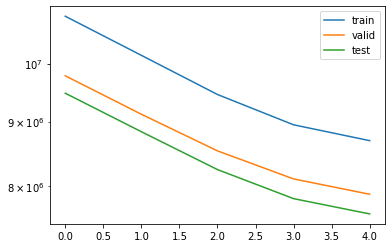

<Figure size 432x288 with 0 Axes>

In [22]:
plt.plot(loss_tr, label="train")
plt.plot(loss_vl, label="valid")
plt.plot(loss_te, label="test")
plt.yscale("log")
plt.legend()
plt.show()
plt.savefig("plot_loss.png")